In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import SimpleImputer
import os
from tqdm import tqdm
import re
import warnings
from sktime.transformations.series.impute import Imputer
# from ABCD import processing_genomics
from ABCD.preprocess import *
warnings.filterwarnings('default')

os             : Linux-4.18.0-372.52.1.el8_6.x86_64-x86_64-with-glibc2.28
python         : 3.10.4
tsai           : 0.3.1
fastai         : 2.7.12
fastcore       : 1.5.29
torch          : 1.11.0+cu102
device         : 1 gpu (['Tesla P100-PCIE-16GB'])
cpu cores      : 4
RAM            : 251.2 GB
GPU memory     : [16.0] GB


# Processing Genomics Data

# Subsetting days

In [17]:
final_out = pd.read_csv('/gpfs/gibbs/pi/gerstein/jjl86/data/ABCD/YL_02_11_ABCD_PRS_c4_features_combined.csv')

In [7]:
genomics = processing_genomics()

In [16]:
genomics

,Unnamed: 0,subjectkey_intersection,PRS_x,PRS_y,fit_ss_first_inbed_minutes_mean,fit_ss_first_sleep_minutes_mean,fit_ss_outbed_minutes_mean,fit_ss_wakeup_minutes_mean,fit_ss_sleepperiod_minutes_mean,fit_ss_wake_minutes_mean,...,fit_ss_sleepperiod_minutes_sd,fit_ss_wake_minutes_sd,fit_ss_light_minutes_sd,fit_ss_deep_minutes_sd,fit_ss_rem_minutes_sd,fit_ss_wake_count_sd,fit_ss_avg_hr_wake_sd,fit_ss_avg_hr_light_sd,fit_ss_avg_hr_deep_sd,fit_ss_avg_hr_rem_sd
0,0,NDAR_INV0J6LY05U,0.000024,-0.022826,-0.917106,-0.763010,0.240683,0.148914,1.614097,0.186144,...,-0.705809,-1.097613,-0.569445,-1.310009,-0.879223,0.143562,-0.453906,-0.752635,-0.490320,-0.964470
1,1,NDAR_INVNNVUN23M,-0.001590,-0.181036,1.384510,1.403105,-0.032453,-0.033419,-1.683119,-0.799891,...,2.518339,1.431652,2.383184,0.940706,1.272714,0.245906,-0.067030,-0.074100,0.289437,-0.499053
2,2,NDAR_INVK9N3BY03,0.002772,0.221652,-0.626666,-0.603332,-0.055403,-0.024897,0.634329,-0.463018,...,0.336649,0.127745,0.217908,0.119081,1.161985,0.057075,-0.027405,-0.154210,-0.013956,-0.025154
3,3,NDAR_INVEJHM574R,0.001569,0.133375,-0.028579,0.020586,0.601465,0.613970,1.003408,-0.433020,...,-1.241983,-0.817675,-1.416799,-0.802216,-0.869620,-0.564323,0.242124,0.229032,0.088646,0.021271
4,4,NDAR_INV1415W413,-0.002539,-0.310822,-0.312640,-0.288524,-0.063669,-0.154765,0.037481,-0.280135,...,-1.639821,-0.770020,-0.527190,-0.895130,0.409310,-0.972655,-0.878159,-0.941636,-1.382149,-1.142816
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1421,1421,NDAR_INV7X576WFP,0.000902,0.037475,-0.899520,-0.914426,-0.605531,-0.641266,-0.483793,0.269509,...,-0.532318,0.051043,-0.048716,-1.415216,-0.183458,-0.668727,1.494767,1.346864,1.074903,1.523369
1422,1422,NDAR_INVG13L2THF,-0.000702,-0.125968,-0.878464,-0.823313,0.130204,0.105088,1.226001,0.456375,...,-0.736252,0.104878,-0.874556,-0.518401,-0.940157,-0.768029,0.240596,-0.083868,0.156495,-0.002283
1423,1423,NDAR_INV5E5N8A4J,0.000966,0.049048,-0.999694,-1.006179,-0.098410,-0.082441,0.841415,1.039527,...,-0.848154,-0.240553,-0.928851,-0.489883,-0.522940,-0.184078,-0.291652,-0.250867,0.369493,-0.054113
1424,1424,NDAR_INVAUWM0VRE,0.000756,0.046139,-0.936368,-0.994350,-0.422719,-0.508142,-0.070534,0.831719,...,-0.929294,0.128834,-1.024376,-0.824721,0.364269,-0.359491,-0.843575,-0.813576,-1.210275,-0.372719


In [23]:
adhd_label = '2022_03_18_label_adhd_group_versus_nonclinical_controls.csv'
anxiety_label = '2022_03_18_label_anxiety_group_versus_nonclinical_controls.csv'
bipolar_label = '2022_03_18_label_bipolar_group_versus_nonclinical_controls.csv'
panic_label = '2022_03_18_label_panic_group_versus_nonclinical_controls.csv'
ocd_label = '2022_03_21_label_ocd_group_versus_nonclinical_controls.csv'
names_dict = {'adhd': adhd_label, 'anxiety': anxiety_label, 'bipolar': bipolar_label, 'panic': panic_label, 'ocd': ocd_label}

group = 'adhd'
df_labels = pd.read_csv(f'/gpfs/slayman/pi/gerstein/jjl86/DATA/ABCD/labels/{names_dict[group]}')
path_of_data, labels = parse_labels(df_labels, '/gpfs/slayman/pi/gerstein/jjl86/DATA/ABCD/aurora01_combined')
# path_of_data, labels = class_balance(np.array(path_of_data), np.array(labels))
path_of_data = list(path_of_data)
labels = list(labels)
list_of_x = []
list_of_y = []
fileNames = []
subjectList = []
print('Begin Preprocessing the Files')
cov_path = '/gpfs/slayman/pi/gerstein/jjl86/DATA/ABCD/covariates_processed.csv'
cov = pd.read_csv(cov_path)
fitted = False
add_genomics = False
add_c4 = True
filter_threshold = 8000
 # set logger to tqdm handler

counter = 0
for index, file in tqdm(enumerate(path_of_data), total = len(path_of_data), desc = "Processing"):
    
    subjectId = parse_file_name(file)
    if add_genomics:
        if len(genomics.loc[genomics['subjectkey_intersection'] == subjectId]) == 0:
            print('No Genomics Info Found')
            continue
    if add_c4:
        if len(final_out.loc[final_out['subjectkey_intersection'] == subjectId]) == 0:
            print('No c4 Info Found')
            continue

    output = SubsettingDay(file, day = [1, 2], filter_threshold = filter_threshold)

    
    if output is None:
        continue
    
    output = add_cov(cov, output, subjectId, cov = names_)
    
    if add_genomics:
        output = add_cov(genomics, output, subjectId, 
                         cov = ['PRS_x', 'PRS_y'], cov_key = 'subjectkey_intersection')
    if add_c4:
        output = add_cov(final_out, output, subjectId, cov = list(final_out)[2:], cov_key = 'subjectkey_intersection')
    
    try:
        output = postprocessing(output, False)
    except:
        continue
    # except TypeError:
    #     print('TypeError in Postprocessing')
    #     continue
    if fitted == False:
        fitted = True
    if not checkNa(output):
        print('Error! Final output still containes NaNs')
        continue 
    print('Success')
    list_of_x.append(output)
    list_of_y.append(labels[index])
    fileNames.append(file)
    subjectList.append(subjectId)

X = np.stack(list_of_x, axis = 0)
Y = np.array(list_of_y)
subjectList = np.array(subjectList)
X = X.transpose([0, 2, 1])

print("normalizing the time-sereis")
X_ts = X[:, 0:7, :]
mean = np.mean(X_ts, axis = (0, 2), keepdims =True)
var = np.var(X_ts, axis = (0, 2), keepdims = True)
X_ts = (X_ts - mean) / np.sqrt(var)

print("normalizing the quantitative features")
X_ = X[:, 7:, :]
if add_genomics:
    X_33 = X_[:,[32, 34, 35, 36, 37],:]
else:
    X_33 = X_[:,[32, 34, 35],:]
mean_33 = np.mean(X_33, axis = 0, keepdims =True)
var_33 = np.var(X_33, axis = 0, keepdims = True)
X_33 = (X_33 - mean_33) / np.sqrt(var_33)

if add_genomics:
    X_[:,[32, 34, 35, 36, 37],:] = X_33
else:
    X_[:,[32, 34, 35],:] = X_33
# Reverse some unwanted normalization
X_out = np.concatenate([X_ts, X_], axis = 1)

np.save(f'./processed_data/Feb23_YL_c4_genomic_all_{filter_threshold}_{group}_non_clinical_2_3_X.npy', X_out)
np.save(f'./processed_data/Feb23_YL_c4_genomic_all_{filter_threshold}_{group}_non_clinical_2_3_subject.npy', subjectList)
np.save(f'./processed_data/Feb23_YL_c4_genomic_all_{filter_threshold}_{group}_non_clinical_2_3_Y.npy', Y)

Begin Preprocessing the Files


Processing:   0%|          | 0/3558 [00:00<?, ?it/s]

No c4 Info Found


/gpfs/gibbs/pi/gerstein/yl2428/YL_ABCD/ABCD/ABCD/preprocess/utils/subsetting_days.py:140: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_df[col_name] = value
/gpfs/gibbs/pi/gerstein/yl2428/YL_ABCD/ABCD/ABCD/preprocess/utils/subsetting_days.py:140: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_df[col_name] = value
/gpfs/gibbs/pi/gerstein/yl2428/YL_ABCD/ABCD/ABCD/preprocess/utils/subsetting_days.py:140: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, wh

No c4 Info Found


...

/gpfs/gibbs/pi/gerstein/yl2428/YL_ABCD/ABCD/ABCD/preprocess/utils/subsetting_days.py:140: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_df[col_name] = value
/gpfs/gibbs/pi/gerstein/yl2428/YL_ABCD/ABCD/ABCD/preprocess/utils/subsetting_days.py:140: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_df[col_name] = value
/gpfs/gibbs/pi/gerstein/yl2428/YL_ABCD/ABCD/ABCD/preprocess/utils/subsetting_days.py:140: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, wh

/gpfs/gibbs/pi/gerstein/yl2428/YL_ABCD/ABCD/ABCD/preprocess/utils/subsetting_days.py:140: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_df[col_name] = value
/gpfs/gibbs/pi/gerstein/yl2428/YL_ABCD/ABCD/ABCD/preprocess/utils/subsetting_days.py:140: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_df[col_name] = value
/gpfs/gibbs/pi/gerstein/yl2428/YL_ABCD/ABCD/ABCD/preprocess/utils/subsetting_days.py:140: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, wh

No c4 Info Found


Processing:   6%|▌         | 217/3558 [00:18<04:44, 11.75it/s]


AssertionError: 

In [13]:
dd

['PRS_x',
 'PRS_y',
 'fit_ss_first_inbed_minutes_mean',
 'fit_ss_first_sleep_minutes_mean',
 'fit_ss_outbed_minutes_mean',
 'fit_ss_wakeup_minutes_mean',
 'fit_ss_sleepperiod_minutes_mean',
 'fit_ss_wake_minutes_mean',
 'fit_ss_light_minutes_mean',
 'fit_ss_deep_minutes_mean',
 'fit_ss_rem_minutes_mean',
 'fit_ss_wake_count_mean',
 'fit_ss_avg_hr_wake_mean',
 'fit_ss_avg_hr_light_mean',
 'fit_ss_avg_hr_deep_mean',
 'fit_ss_avg_hr_rem_mean',
 'fit_ss_first_inbed_minutes_min',
 'fit_ss_first_sleep_minutes_min',
 'fit_ss_outbed_minutes_min',
 'fit_ss_wakeup_minutes_min',
 'fit_ss_sleepperiod_minutes_min',
 'fit_ss_wake_minutes_min',
 'fit_ss_light_minutes_min',
 'fit_ss_deep_minutes_min',
 'fit_ss_rem_minutes_min',
 'fit_ss_wake_count_min',
 'fit_ss_avg_hr_wake_min',
 'fit_ss_avg_hr_light_min',
 'fit_ss_avg_hr_deep_min',
 'fit_ss_avg_hr_rem_min',
 'fit_ss_first_inbed_minutes_max',
 'fit_ss_first_sleep_minutes_max',
 'fit_ss_outbed_minutes_max',
 'fit_ss_wakeup_minutes_max',
 'fit_ss_sleep

In [15]:
adhd_label = '2022_03_18_label_adhd_group_versus_nonclinical_controls.csv'
anxiety_label = '2022_03_18_label_anxiety_group_versus_nonclinical_controls.csv'
bipolar_label = '2022_03_18_label_bipolar_group_versus_nonclinical_controls.csv'
panic_label = '2022_03_18_label_panic_group_versus_nonclinical_controls.csv'
ocd_label = '2022_03_21_label_ocd_group_versus_nonclinical_controls.csv'
names_dict = {'adhd': adhd_label, 'anxiety': anxiety_label, 'bipolar': bipolar_label, 'panic': panic_label, 'ocd': ocd_label}

group = 'anxiety'
df_labels = pd.read_csv(f'/gpfs/slayman/pi/gerstein/jjl86/DATA/ABCD/labels/{names_dict[group]}')
path_of_data, labels = parse_labels(df_labels, '/gpfs/slayman/pi/gerstein/jjl86/DATA/ABCD/aurora01_combined')
# path_of_data, labels = class_balance(np.array(path_of_data), np.array(labels))
path_of_data = list(path_of_data)
labels = list(labels)
list_of_x = []
list_of_y = []
fileNames = []
subjectList = []
print('Begin Preprocessing the Files')
cov_path = '/gpfs/slayman/pi/gerstein/jjl86/DATA/ABCD/covariates_processed.csv'
cov = pd.read_csv(cov_path)
fitted = False
add_genomics = True
filter_threshold = 8000
 # set logger to tqdm handler

counter = 0
for index, file in tqdm(enumerate(path_of_data), total = len(path_of_data), desc = "Processing"):
    
    subjectId = parse_file_name(file)
    # if add_genomics:
    #     if len(genomics.loc[genomics['subjectkey_intersection'] == subjectId]) == 0:
    #         print('No Genomics Info Found')
    #         continue
    try:
        output = SubsettingDay(file, day = [1, 2], filter_threshold = 8000)
    except AssertionError:
        print('Subsetting failure, value error')
        continue
    
    if output is None:
        continue
    
    output = add_cov(cov, output, subjectId, cov = names_)
    
    if add_genomics:
        output = add_cov(genomics, output, subjectId, 
                         cov = list(genomics)[2:], cov_key = 'subjectkey_intersection')

    output = postprocessing(output, False)
    # except TypeError:
    #     print('TypeError in Postprocessing')
    #     continue
    if fitted == False:
        fitted = True
    if not checkNa(output):
        print('Error! Final output still containes NaNs')
        continue 
    print('Success')
    list_of_x.append(output)
    list_of_y.append(labels[index])
    fileNames.append(file)
    subjectList.append(subjectId)

X = np.stack(list_of_x, axis = 0)
Y = np.array(list_of_y)
subjectList = np.array(subjectList)
X = X.transpose([0, 2, 1])

X_ts = X[:, 0:7, :]
mean = np.mean(X_ts, axis = (0, 2), keepdims =True)
var = np.var(X_ts, axis = (0, 2), keepdims = True)
X_ts = (X_ts - mean) / np.sqrt(var)

X_ = X[:, 7:, :]
if add_genomics:
    X_33 = X_[:,[32, 34, 35, 36, 37],:]
else:
    X_33 = X_[:,[32, 34, 35],:]
mean_33 = np.mean(X_33, axis = 0, keepdims =True)
var_33 = np.var(X_33, axis = 0, keepdims = True)
X_33 = (X_33 - mean_33) / np.sqrt(var_33)

if add_genomics:
    X_[:,[32, 34, 35, 36, 37],:] = X_33
else:
    X_[:,[32, 34, 35],:] = X_33
# Reverse some unwanted normalization
X_out = np.concatenate([X_ts, X_], axis = 1)
if add_genomics:
    np.save(f'/gpfs/slayman/pi/gerstein/jjl86/DATA/ABCD/processed_data/new_genomic_all_{filter_threshold}_{group}_non_clinical_2_3_X.npy', X_out)
    np.save(f'/gpfs/slayman/pi/gerstein/jjl86/DATA/ABCD/processed_data/new_genomic_all_{filter_threshold}_{group}_non_clinical_2_3_subject.npy', subjectList)
    np.save(f'/gpfs/slayman/pi/gerstein/jjl86/DATA/ABCD/processed_data/new_genomic_all_{filter_threshold}_{group}_non_clinical_2_3_Y.npy', Y)
else:
    np.save(f'/gpfs/slayman/pi/gerstein/jjl86/DATA/ABCD/processed_data/all_{filter_threshold}_{group}_non_clinical_2_3_X.npy', X_out)
    np.save(f'/gpfs/slayman/pi/gerstein/jjl86/DATA/ABCD/processed_data/all_{filter_threshold}_{group}_non_clinical_2_3_subject.npy', subjectList)
    np.save(f'/gpfs/slayman/pi/gerstein/jjl86/DATA/ABCD/processed_data/all_{filter_threshold}_{group}_non_clinical_2_3_Y.npy', Y)

Begin Preprocessing the Files


Processing:   0%|          | 0/4459 [00:00<?, ?it/s]
/gpfs/gibbs/pi/gerstein/yl2428/YL_ABCD/ABCD/ABCD/preprocess/utils/subsetting_days.py:149: DeprecationWarning: invalid escape sequence '\w'
  get_subject_id_from_file_name = lambda file: re.search('(NDAR_\w*)_combined\.csv', file).group(1)
/gpfs/gibbs/pi/gerstein/yl2428/YL_ABCD/ABCD/ABCD/preprocess/utils/subsetting_days.py:150: DeprecationWarning: invalid escape sequence '\w'
  get_subject_id_from_file_name = lambda file: re.search('(NDAR\w*)_combined\.csv', file).group(1)
/gpfs/gibbs/pi/gerstein/yl2428/YL_ABCD/ABCD/ABCD/preprocess/utils/subsetting_days.py:154: DeprecationWarning: invalid escape sequence '\w'
  file = re.search('(NDAR\w*)_combined\.csv', file).group(1)


IndexError: list index out of range

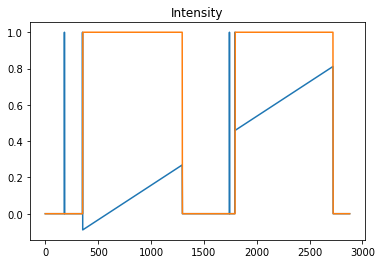

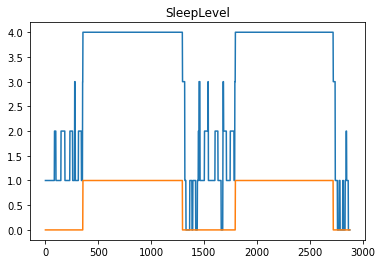

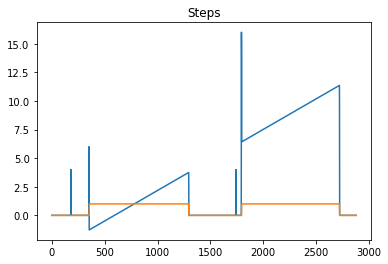

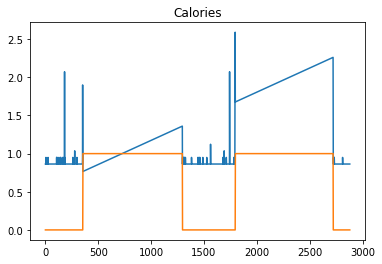

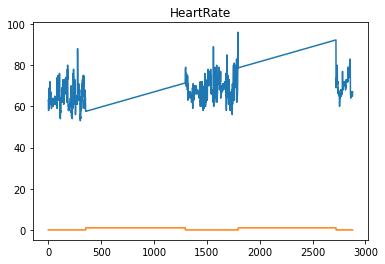

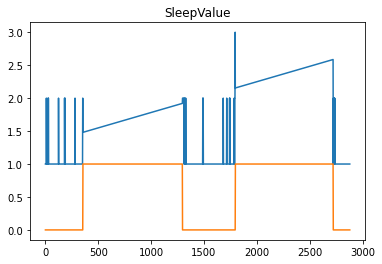

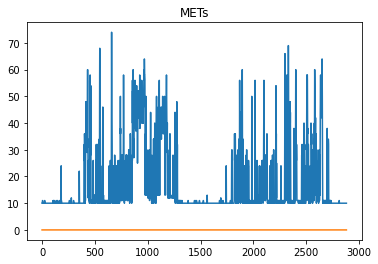

In [70]:
for i in range(7):
    plt.plot(output[:, i])
    plt.plot(output[:,-7 + i])
    plt.title(ts[i])
    plt.show()